# CycleGAN Vergleichs-Inference (mehrere Runs)

Wählt die neuesten CycleGAN-Experimente (oder explizite Checkpoints), zieht 5 Zufallsbilder aus einem Eingabe-Ordner, generiert alle Outputs, speichert sie unter `results/cyclegan_inference/<exp>/<direction>` und zeigt Eingabe + alle Ausgaben nebeneinander. Die Eingaben werden für die GAN-Inference fest auf 512x512 resized; Crop und Horizontal-Flip sind deaktiviert. Die Anzahl der Spalten richtet sich nach der Anzahl der Checkpoints.


In [98]:
from pathlib import Path
import os, random, torch
from PIL import Image
from matplotlib import pyplot as plt

os.chdir("/srv/store/docker-users/thesis/khajuria/day2night")
print("Working dir:", os.getcwd())

# Parameter anpassen
INPUT_DIR = Path("data/finaldataset/testA")#Path("data/day2night1000/testA") #Path("data/Straßen Bilder/test")
NUM_SAMPLES = 5
INFERENCE_SIZE = [720, 720]  # festes Resize vor der GAN-Inference: [H, W]
DIRECTION = "day2night"  # oder "night2day"
CHECKPOINT_FILE = Path("notebooks/thesis_exp/711/files.txt")
FIGURE_PATH = CHECKPOINT_FILE.parent / f"{CHECKPOINT_FILE.parent.name}.png"
BASE_CONFIG = Path("configs/cyclegan.yaml")
OUTPUT_ROOT = Path("results/cyclegan_inference_demo")
PLOT_COL_WIDTH = 6.0  # Breite pro Bildspalte in inches
PLOT_AXES_PAD = 0.02  # gleicher Abstand zwischen Spalten und Zeilen in inches
PLOT_TITLE_PAD = 4  # Abstand der Spaltentitel zur ersten Bildreihe
PLOT_TITLE_FONTSIZE = 18  # Schriftgröße der Spaltenlabels
#SEED = 43 #64 #56
SEED = 57 #64 bad
random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda:4" if torch.cuda.is_available() else "cpu")


Working dir: /srv/store/docker-users/thesis/khajuria/day2night


In [99]:
# Vorgegebene Bildliste verwenden statt zufaelligem Sampling
VORGEGEBENE_LISTE = False

BILDERLISTE = [
    "day_0722_score0.814109_street_2964_2018-06-25_09-40-42_161__2018-06-25_09-54-54_955.jpg",
    "day_1336_score0.391505_street_7974_2018-06-18_19-00__2018-06-18_19-14-19_347.jpg",
    "day_0232_score0.753627_street_7089_2018-06-25_09-40-42_161__2018-06-25_09-57-34_052.jpg",
    "day_1224_score0.514989_street_5296_2018-06-18_19-00__2018-06-18_20-06-09_380.jpg",
    "day_0024_score0.361994_street_4767_2018-06-18_19-00__2018-06-18_18-59-34_362.jpg",
    "day_1072_score0.452741_street_4099_2018-06-18_19-00__2018-06-18_19-40-37_573.jpg"
    ]

if VORGEGEBENE_LISTE:
    NUM_SAMPLES = len(BILDERLISTE)
    print(f"Vorgegebene Bilderliste mit {NUM_SAMPLES} Bildern wird verwendet.")

In [100]:
from src.utils.common import load_cfg
from src.apply_cyclegan import (
    build_inference_transform,
    build_generator,
    tensor_to_pil,
    gather_image_paths,
)

def load_state_dict(path: Path):
    try:
        return torch.load(path, map_location="cpu", weights_only=True)
    except TypeError:
        return torch.load(path, map_location="cpu")

def read_ckpt_file(path: Path) -> list[tuple[str, Path]]:
    if not path.is_file():
        raise FileNotFoundError(f"Checkpoint-Datei nicht gefunden: {path}")

    entries = []
    for line_no, raw_line in enumerate(path.read_text().splitlines(), start=1):
        line = raw_line.strip()
        if not line or line.startswith("#"):
            continue
        if ":" not in line:
            raise ValueError(f"Ungültige Zeile {line_no} in {path}: {raw_line!r}")
        label, ckpt = line.split(":", 1)
        label = label.strip()
        ckpt = Path(ckpt.strip())
        if not label:
            raise ValueError(f"Leeres Label in Zeile {line_no} von {path}")
        if not ckpt.is_file():
            raise FileNotFoundError(f"Checkpoint für Label {label!r} nicht gefunden: {ckpt}")
        entries.append((label, ckpt))

    if not entries:
        raise ValueError(f"Keine Checkpoints in {path}")
    return entries

def cfg_for_ckpt(ckpt: Path):
    local_cfgs = sorted(ckpt.parent.glob("*.yaml"))
    if local_cfgs:
        cfg = load_cfg(local_cfgs[0])
    else:
        cfg = load_cfg(BASE_CONFIG)

    cfg.setdefault("transforms", {})
    cfg["transforms"].update(
        {
            "resize": INFERENCE_SIZE,
            "center_crop": None,
            "random_crop": None,
            "random_flip": False,
        }
    )
    return cfg

ckpt_entries = read_ckpt_file(CHECKPOINT_FILE)
ckpt_labels = [label for label, _ in ckpt_entries]
ckpts = [ckpt for _, ckpt in ckpt_entries]
print("Checkpoints (Reihenfolge = Spaltenreihenfolge):")
for label, ckpt in ckpt_entries:
    print(f" - {label}: {ckpt}")

base_cfg = load_cfg(BASE_CONFIG)
extensions = base_cfg.get("data", {}).get("extensions", ("jpg", "jpeg", "png", "bmp", "tif", "tiff"))
image_paths = gather_image_paths(INPUT_DIR, extensions)
assert image_paths, f"Keine Bilder in {INPUT_DIR}"
if VORGEGEBENE_LISTE:
    sample_paths = [INPUT_DIR / filename for filename in BILDERLISTE]
    missing_paths = [path for path in sample_paths if not path.is_file()]
    if missing_paths:
        missing = "\n".join(f" - {path}" for path in missing_paths)
        raise FileNotFoundError(f"Folgende Dateien aus BILDERLISTE fehlen in {INPUT_DIR}:\n{missing}")
    print(f"Verwende {len(sample_paths)} Bilder aus BILDERLISTE in {INPUT_DIR}")
else:
    sample_paths = random.sample(image_paths, min(NUM_SAMPLES, len(image_paths)))
    print(f"Verwende {len(sample_paths)} Zufallsbilder aus {INPUT_DIR}")
print("Ausgewählte Dateien:")
for path in sample_paths:
    print(f" - {path.relative_to(INPUT_DIR)}")


Checkpoints (Reihenfolge = Spaltenreihenfolge):
 - Ours (aktive & passive Führung): experiments/lastchance_semgan_20260613_023510/latest.pt
Verwende 5 Zufallsbilder aus data/finaldataset/testA
Ausgewählte Dateien:
 - day_0088_score0.394251_street_5798_2018-06-18_19-00__2018-06-18_20-11-21_886.jpg
 - day_0754_score0.531183_street_6645_2018-06-18_19-00__2018-06-18_19-55-42_394.jpg
 - day_1208_score0.519981_street_7406_2018-06-19_10-00__2018-06-19_10-06-52_183.jpg
 - day_1240_score0.482117_street_4689_2018-06-18_19-00__2018-06-18_20-02-56_875.jpg
 - day_0040_score0.460134_street_0161_2018-06-18_19-00__2018-06-18_20-05-52_884.jpg


In [101]:
def run_generator(ckpt: Path):
    cfg = cfg_for_ckpt(ckpt)
    transform = build_inference_transform(cfg)
    generator = build_generator(cfg, device, DIRECTION)
    state = load_state_dict(ckpt)
    key = "G" if DIRECTION == "day2night" else "F"
    generator.load_state_dict(state[key])
    generator.eval()
    out_dir = OUTPUT_ROOT / ckpt.parent.name / DIRECTION
    out_dir.mkdir(parents=True, exist_ok=True)

    saved = {}  # str(input_path) -> output_path
    brightness_gain = float(cfg.get("inference", {}).get("brightness_gain", 1.0))
    output_gamma = float(cfg.get("inference", {}).get("output_gamma", 1.0))

    with torch.inference_mode():
        for path in sample_paths:
            img = Image.open(path).convert("RGB")
            inp = transform(img).unsqueeze(0).to(device)
            out = generator(inp)
            pil = tensor_to_pil(out, brightness_gain=brightness_gain, output_gamma=output_gamma)
            dest = out_dir / path.relative_to(INPUT_DIR)
            dest.parent.mkdir(parents=True, exist_ok=True)
            pil.save(dest)
            saved[str(path)] = dest
    print(f"Gespeichert unter {out_dir}")
    return saved

results = {}  # label -> {input_path_str: output_path}
for label, ckpt in ckpt_entries:
    print(f"Generiere {label}: {ckpt}")
    results[label] = run_generator(ckpt)


Generiere Ours (aktive & passive Führung): experiments/lastchance_semgan_20260613_023510/latest.pt
Building day2night generator | encoder: experiments/seg_20251211_162810/encoder_GE.pth | freeze=True


Gespeichert unter results/cyclegan_inference_demo/lastchance_semgan_20260613_023510/day2night


Gesamtgrafik gespeichert unter notebooks/thesis_exp/711/711.png


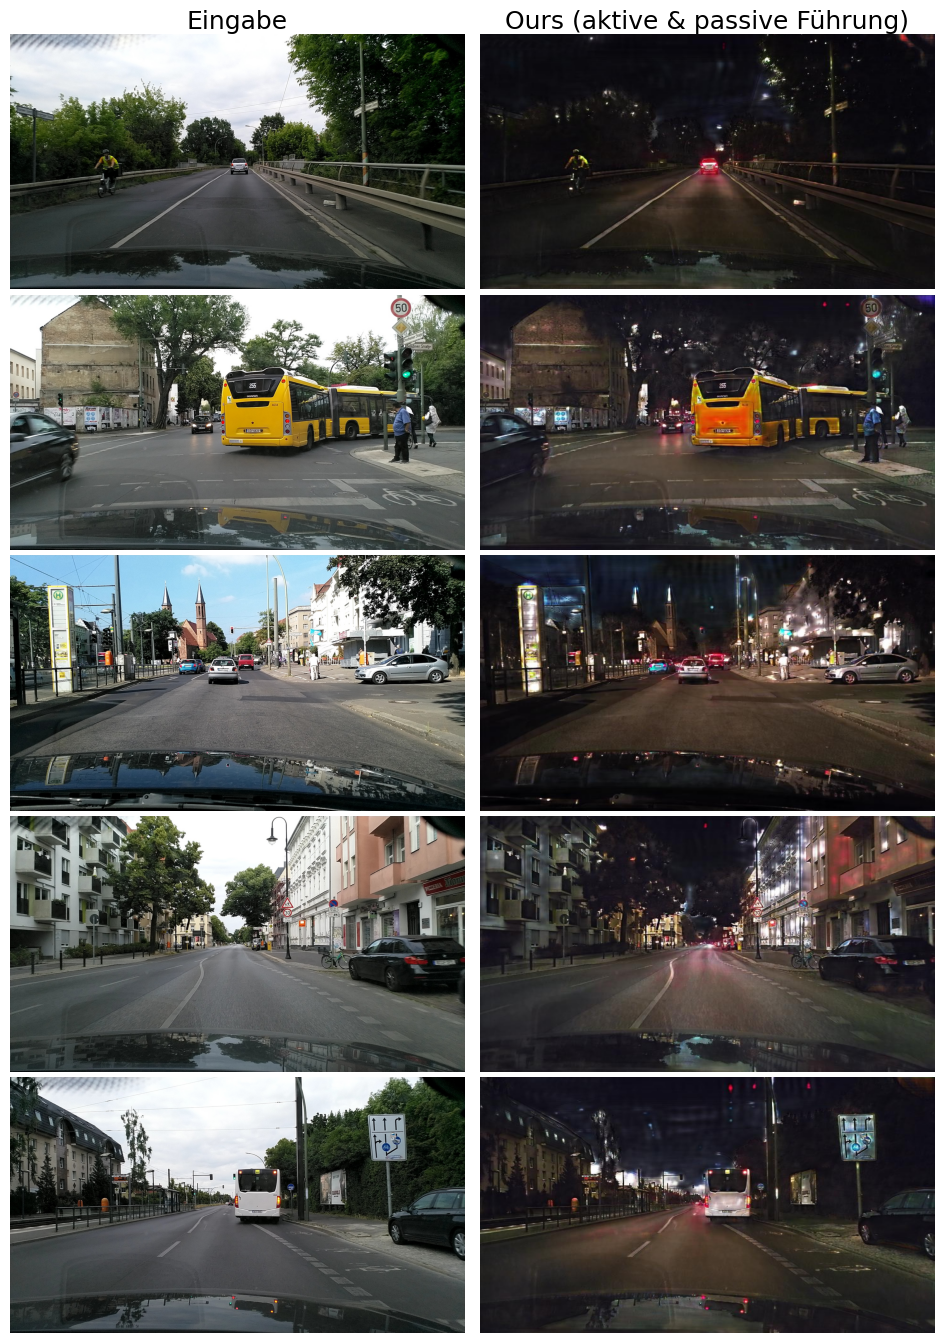

In [102]:
# Visualisierung: Eingabe + eine Spalte pro Checkpoint-Label
result_labels = list(results.keys())  # behält Reihenfolge aus CHECKPOINT_FILE
column_labels = ["Eingabe", *result_labels]
rows = len(sample_paths)
cols = len(column_labels)

with Image.open(sample_paths[0]) as first_img:
    img_w, img_h = first_img.size
image_aspect = img_w / img_h
row_height = PLOT_COL_WIDTH / image_aspect
fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(PLOT_COL_WIDTH * cols, row_height * rows),
    squeeze=False,
)
fig.subplots_adjust(wspace=PLOT_AXES_PAD, hspace=PLOT_AXES_PAD)
axes = axes.ravel()

for row, img_path in enumerate(sample_paths):
    imgs = [Image.open(img_path)]
    for label in result_labels:
        out_path = results[label][str(img_path)]
        imgs.append(Image.open(out_path))

    for col, im in enumerate(imgs):
        ax = axes[row * cols + col]
        ax.imshow(im, aspect="auto")
        ax.set_box_aspect(img_h / img_w)
        if row == 0:
            ax.set_title(column_labels[col], pad=PLOT_TITLE_PAD, fontsize=PLOT_TITLE_FONTSIZE)
        ax.axis("off")

FIGURE_PATH.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURE_PATH, dpi=200, bbox_inches="tight")
print(f"Gesamtgrafik gespeichert unter {FIGURE_PATH}")
plt.show()
